# Opis Cech Danych (Features) - Stanford Open Policing Project

## 1. Cechy Identyfikacyjne i Czasoprzestrzenne

      **date** (Data): Data zatrzymania.


      **time** (Czas): Czas zatrzymania.


      **location** (String): Lokalizacja zatrzymania (np. skrzyżowanie, ulica).


      **latitude** (Float): Szerokość geograficzna zatrzymania.


      **longitude** (Float): Długość geograficzna zatrzymania.


      **county_name** (String): Nazwa hrabstwa, w którym miało miejsce zatrzymanie.


      **officer_id** (String): Zanonimizowany unikalny identyfikator funkcjonariusza.


      **stop_id** (Integer): Unikalny identyfikator dla każdego zatrzymania.


## 2. Cechy Demograficzne i Powód Zatrzymania

      **driver_gender** (String): Płeć kierowcy.


      **driver_age** (Integer): Wiek kierowcy w chwili zatrzymania.


      **driver_race** (String): Rasa / Grupa etniczna kierowcy (np. White, Black, Hispanic).


      **violation** (String): Główna przyczyna/powód zatrzymania.


      **reason_for_stop** (String): Kategoria naruszenia (np. Equipment, Moving Violation, Other).


## 3. Cechy Wynikowe i Działania Policji

      **search_conducted** (Boolean): Czy przeprowadzono przeszukanie kierowcy lub pojazdu (TRUE/FALSE).


      **contraband_found** (Boolean): Czy znaleziono kontrabandę podczas przeszukania (TRUE/FALSE).


      **drugs_related_stop** (Boolean): Czy zatrzymanie było powiązane z narkotykami (TRUE/FALSE).


      **seizure_type** (String): Rodzaj zajętych przedmiotów (jeśli dotyczy).


      **warning_issued** (Boolean): Czy wydano pisemne ostrzeżenie (TRUE/FALSE).


      **citation_issued** (Boolean): Czy wydano mandat / wezwanie do sądu (TRUE/FALSE).


      **arrest_made** (Boolean): Czy dokonano aresztowania (TRUE/FALSE).


      **frisk_performed** (Boolean): Czy dokonano przeszukania osobistego (frisk) kierowcy (TRUE/FALSE).


## 4. Dodatkowe Cechy Związane z Przeszukanym Pojazdem


      **search_type** (String): Rodzaj przeszukania (np. Probable Cause, Consent, Inventory).


      **reason_for_search** (String): Podany powód, dla którego przeprowadzono przeszukanie.


      **vehicle_type** (String): Rodzaj zatrzymanego pojazdu.

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import random

# Pełna lista 41 poprawnych nazw kolumn (cech). W tym przypadku, stop_id zostanie użyte do wczytania danych,
# a następnie zignorowane (lub użyte jako nazwa indeksu)
COLUMN_NAMES = [
    'stop_id', 'date', 'time', 'location', 'latitude', 'longitude', 'district', 'driver_age', 'driver_height',
    'driver_weight', 'driver_race', 'driver_gender', 'subject_id', 'reason_for_stop', 'violation',
    'search_conducted', 'contraband_found', 'drugs_related_stop', 'warning_issued', 'citation_issued',
    'arrest_made', 'frisk_performed', 'reason_for_search', 'search_type', 'search_basis',
    'reason_for_search_type', 'disposition', 'raw_row_number', 'violation_raw', 'state', 'county_name',
    'county_fips', 'fine_amount', 'vehicle_make', 'vehicle_model', 'vehicle_color', 'vehicle_year',
    'vehicle_type', 'vehicle_registration_state', 'out_of_state', 'equipment_violation'
]

# Lista nazw dla pozostałych 40 kolumn danych (bez 'stop_id', który jest indeksem)
DATA_COLUMN_NAMES = COLUMN_NAMES[1:]

CHUNK_DIRECTORY = '.'
CHUNK_PREFIX = 'tn_nashville_chunk_'
SEARCH_PATTERN = os.path.join(CHUNK_DIRECTORY, f"{CHUNK_PREFIX}*.csv")


def display_random_sample_from_chunks():
    # Znajduje wszystkie pliki pasujące do wzorca
    chunk_files = glob.glob(SEARCH_PATTERN)

    if not chunk_files:
        print(f"BŁĄD: Nie znaleziono plików pasujących do wzorca '{SEARCH_PATTERN}'.")
        return

    # Sortuje pliki
    sorted_files = sorted(chunk_files)

    # Indeks 31 odpowiada 32. wierszowi (indeksowanie od 0)
    TARGET_ROW_INDEX = 31

    for file_path in sorted_files:
        try:
            # KLUCZOWA ZMIANA: Przywrócono index_col=0, aby poprawnie zarządzać kolumną indeksu,
            # której obecność w plikach CSV powodowała przesunięcie.
            # W tym wariancie, Pandas użyje pierwszej kolumny (faktycznie stop_id) jako indeksu.
            df_chunk = pd.read_csv(
                file_path,
                names=COLUMN_NAMES,
                header=None,
                index_col=0,
                low_memory=False
            )

            if len(df_chunk) <= TARGET_ROW_INDEX:
                print(f"\n[PLIK: {os.path.basename(file_path)}] - Ostrzeżenie: Plik ma tylko {len(df_chunk)} wierszy. Omijam.")
                continue

            # Wybiera 32. wiersz (indeks 31)
            # Pobiera pozostałe 40 kolumn danych (bez stop_id)
            random_sample_values = df_chunk.iloc[TARGET_ROW_INDEX].values

            # Wartość stop_id jest teraz indeksem wiersza w DataFrame
            stop_id_value = df_chunk.index[TARGET_ROW_INDEX]

            # Wyświetla nazwę pliku
            print(f"\n[PLIK: {os.path.basename(file_path)}] - Wyświetlono 32. wiersz")

            # Wartość stop_id jest odczytywana z indeksu
            print(f"STOP_ID: {stop_id_value}")

            # Wyświetla pozostałe 40 wartości z ich etykietami
            for label, value in zip(DATA_COLUMN_NAMES, random_sample_values):
                print(f"{label}: {value}")

        except Exception as e:
            print(f"\nBŁĄD podczas przetwarzania pliku {file_path}: {e}")


if __name__ == "__main__":
    display_random_sample_from_chunks()


BŁĄD: Nie znaleziono plików pasujących do wzorca './tn_nashville_chunk_*.csv'.


# Analiza danych

## Analiza rozkładów poszczególnych zmiennych

In [ ]:
from google.colab import output

In [ ]:
# Naprawia błedy z kompatybilnością dependacies
# Czasami nie trzeba, nie wiem

!pip install mlxtend
!pip install dython
!pip uninstall -y numpy scipy
!pip install numpy scipy

output.clear()

In [ ]:
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow\(\) is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now\(datetime.UTC\).")

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
from dython.nominal import associations
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

try:
    df = pd.read_csv("nashville_sample.csv", low_memory=False)
except:
    df = pd.read_xls("nashville_sample.xls", low_memory=False)

sns.set(style="whitegrid", rc={'figure.figsize':(10, 6)})

output.clear()
print(df.columns.values)

ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

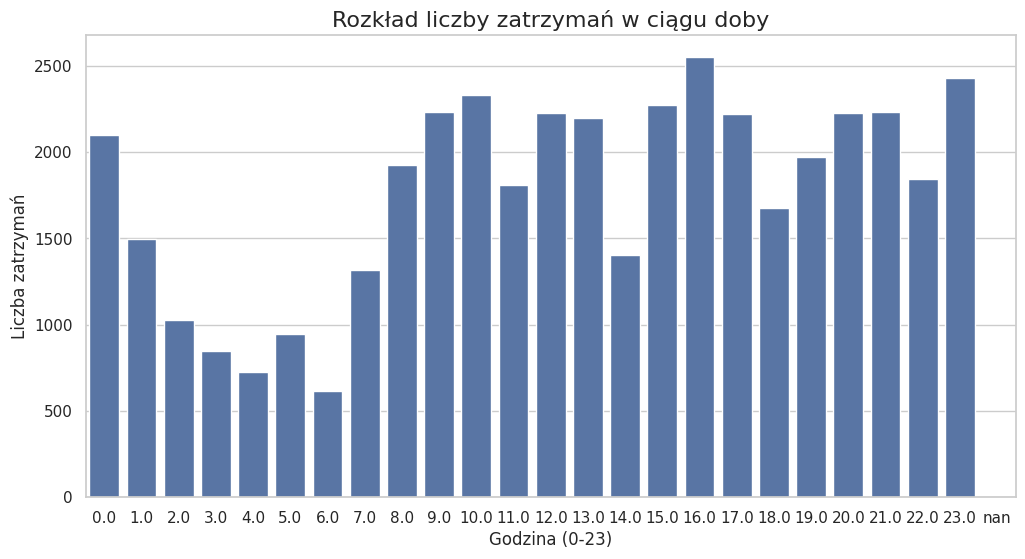

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

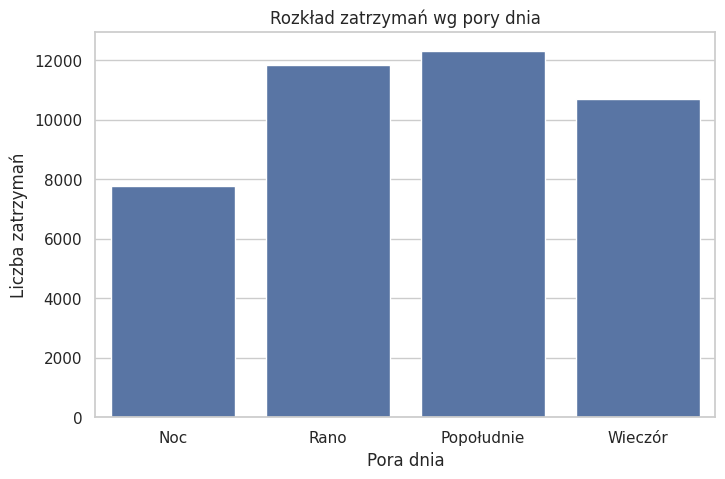

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
time_df = pd.DataFrame()
time_df["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
time_df["hour_of_day"] = time_df["time_obj"].dt.hour

hourly_distribution = time_df["hour_of_day"].value_counts().sort_index()
hourly_order = sorted(time_df['hour_of_day'].unique())

plt.figure(figsize=(12, 6))
sns.countplot(
    x='hour_of_day',
    data=time_df,
    order=hourly_order,
)
plt.title('Rozkład liczby zatrzymań w ciągu doby', fontsize=16)
plt.xlabel('Godzina (0-23)')
plt.ylabel('Liczba zatrzymań')
plt.show()

bins = [-1, 6, 12, 18, 24]
labels = ["Noc", "Rano", "Popołudnie", "Wieczór"]

time_df["day_timeframe"] = pd.cut(
    time_df["hour_of_day"],
    bins=bins,
    labels=labels,
    right=True
)
plt.figure(figsize=(8, 5))
sns.countplot(x='day_timeframe', data=time_df, order=labels)
plt.title('Rozkład zatrzymań wg pory dnia')
plt.xlabel('Pora dnia')
plt.ylabel('Liczba zatrzymań')
plt.show()


Analiza rozkładu kolumny: subject_age
Rozkład:
count    42691.000000
mean        37.073458
std         14.061315
min         13.000000
25%         26.000000
50%         34.000000
75%         47.000000
max         99.000000
Name: subject_age, dtype: float64

Skośność i kurtoza:
Skośność: 0.7621847230215409
Kurtoza: -0.0323075571353173
Rozkład jest prawostronnie skośny (więcej młodych osób).


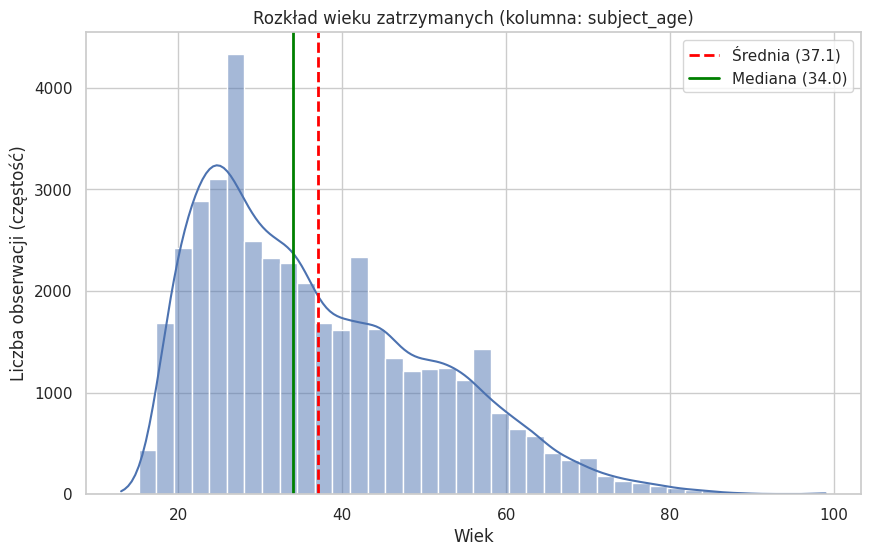

In [ ]:
anal_col = "subject_age"

# Analiza wieku
print(f"\nAnaliza rozkładu kolumny: {anal_col}")
print("Rozkład:")
print(df[anal_col].describe())

print("\nSkośność i kurtoza:")
skosnosc = df[anal_col].skew()
kurtoza = df[anal_col].kurtosis()
print(f"Skośność: {skosnosc}")
print(f"Kurtoza: {kurtoza}")

if skosnosc > 0.5:
        print("Rozkład jest prawostronnie skośny (więcej młodych osób).")
elif skosnosc < -0.5:
    print("Rozkład jest lewostronnie skośny (więcej starszych osób).")
else:
    print("Rozkład jest w przybliżeniu symetryczny.")

# Wykres rozkładu
plt.figure(figsize=(10, 6))
sns.histplot(df[anal_col], kde=True, bins=40)

# Średnia
plt.axvline(
    df[anal_col].mean(), color='red', linestyle='--', linewidth=2,
    label=f'Średnia ({df[anal_col].mean():.1f})'
)
# Mediana
plt.axvline(
    df[anal_col].median(), color='green', linestyle='-', linewidth=2,
    label=f'Mediana ({df[anal_col].median():.1f})'
)

plt.title(f'Rozkład wieku zatrzymanych (kolumna: {anal_col})')
plt.xlabel('Wiek')
plt.ylabel('Liczba zatrzymań')
plt.legend()
plt.show()


Zatrzymania według rasy
Udział procentowy: subject_race
white                      54.2%
black                     37.63%
hispanic                   5.31%
asian/pacific islander     1.33%
unknown                     1.2%
other                      0.33%
Name: proportion, dtype: object


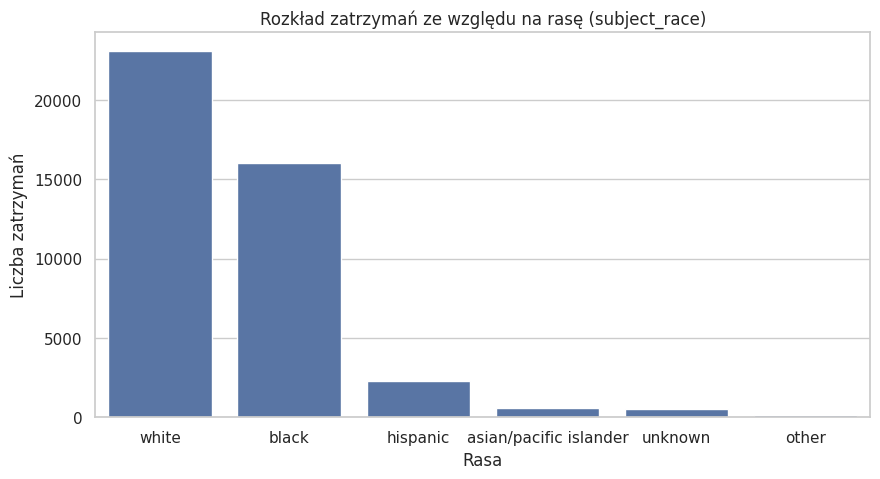

In [ ]:
# Analiza rasy
anal_col = "subject_race"
print("\nZatrzymania według rasy")
print(f"Udział procentowy: {(df[anal_col].value_counts(normalize=True) * 100).round(2).astype(str) + '%'}")

# Wykres
plt.figure(figsize=(10, 5)) # Definiujemy rozmiar dla tego konkretnego wykresu
sns.countplot(x='subject_race', data=df, order=df['subject_race'].value_counts().index)
plt.title('Rozkład zatrzymań ze względu na rasę (subject_race)')
plt.xlabel('Rasa')
plt.ylabel('Liczba zatrzymań')
plt.xticks(rotation=45, ha='right') # Dodano obrót o 45 stopni i wyrównanie do prawej
plt.tight_layout() # Opcjonalnie, aby dopasować etykiety i zapobiec ich obcinaniu
plt.show()

subject_sex
male      25272
female    17260
Name: count, dtype: int64

Procent
subject_sex
male      59.42%
female    40.58%
Name: proportion, dtype: object


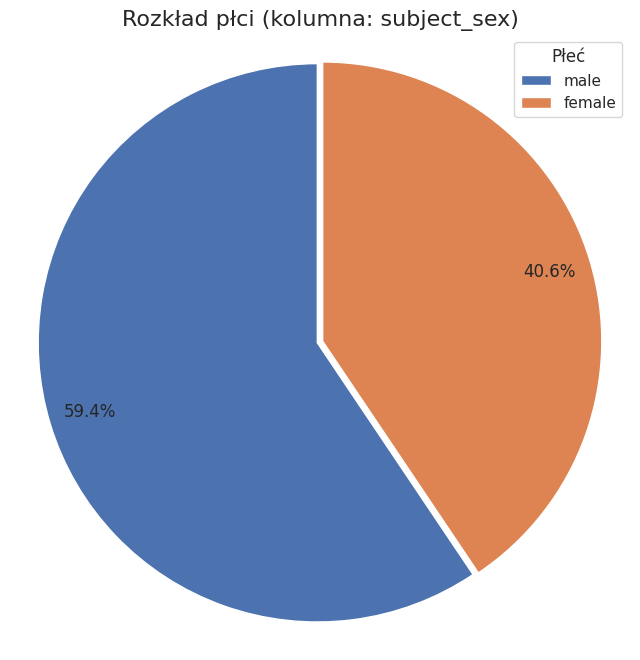

In [ ]:
counts = df["subject_sex"].value_counts()
print(counts)

print("\nProcent")
percentages = (df["subject_sex"].value_counts(normalize=True) * 100).round(2)
print(percentages.astype(str) + '%')

counts = df["subject_sex"].value_counts()
plt.figure(figsize=(8, 8))
counts.plot(
        kind='pie',
        autopct='%1.1f%%',
        startangle=90,
        labels=None,
        pctdistance=0.85,
        explode=[0.01] * len(counts)
    )

plt.title(f'Rozkład płci (kolumna: {"subject_sex"})', fontsize=16)
plt.ylabel('')
plt.legend(counts.index, title="Płeć", loc="best")
plt.axis('equal')

plt.show()

Zatrzymania według wykroczenia
Liczba unikalnych typów wykroczeń: 8

Top 10 najczęstszych wykroczeń:
violation
moving traffic violation       21258
vehicle equipment violation    13711
registration                    2649
safety violation                2614
seatbelt violation              1425
investigative stop               827
parking violation                105
child restraint                   18
Name: count, dtype: int64

Udział procentowy:
violation
moving traffic violation       49.89%
vehicle equipment violation    32.18%
registration                    6.22%
safety violation                6.14%
seatbelt violation              3.34%
investigative stop              1.94%
parking violation               0.25%
child restraint                 0.04%
Name: proportion, dtype: object


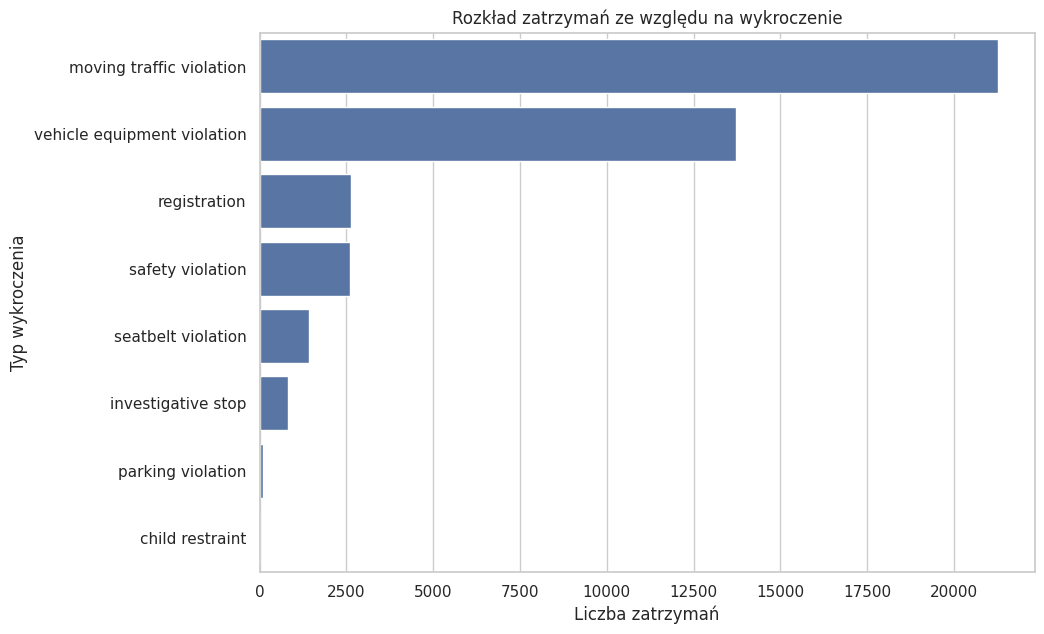

In [ ]:
print("Zatrzymania według wykroczenia")
print(f"Liczba unikalnych typów wykroczeń: {df['violation'].nunique()}")

# Ilość wystąpień
print("\nTop 10 najczęstszych wykroczeń:")
top_10_violations = df['violation'].value_counts()
print(top_10_violations)

# Procenty wystąpień
print("\nUdział procentowy:")
print((df['violation'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

plt.figure(figsize=(10, 7))
sns.countplot(
    y='violation',
    data=df,
    order=top_10_violations.index
)
plt.title('Rozkład zatrzymań ze względu na wykroczenie')
plt.xlabel('Liczba zatrzymań')
plt.ylabel('Typ wykroczenia')
plt.show()

Liczba przeszukań (ignorując brak przeszukań)
search_basis
consent           946
other             340
plain view        218
probable cause    206
Name: count, dtype: int64

Udział procentowy:
search_basis
consent           55.32%
other             19.88%
plain view        12.75%
probable cause    12.05%
Name: proportion, dtype: object


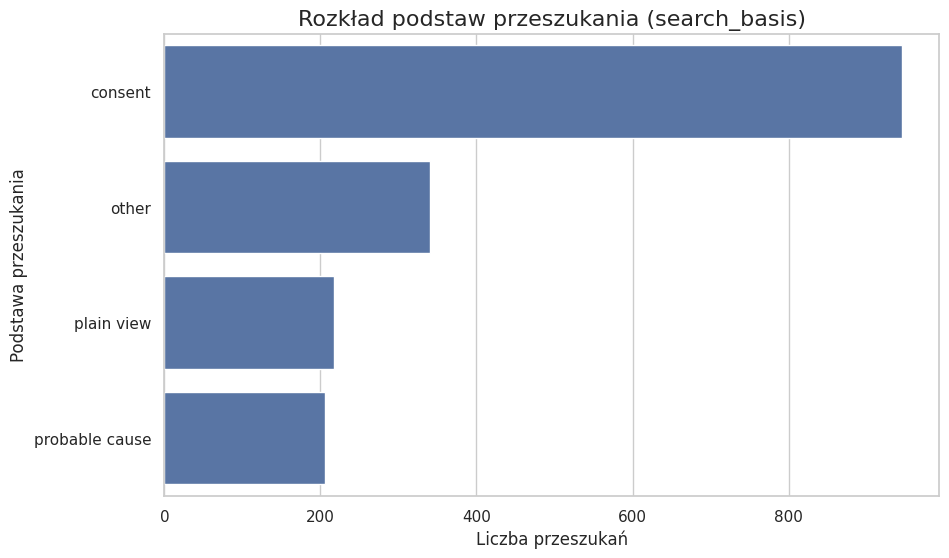

In [ ]:
# Rozkład podstawy przeszukania

column = "search_basis"
counts_nan = df[column].value_counts(dropna=True)

print("Liczba przeszukań (ignorując brak przeszukań)")
print(counts_nan)

percent = ((df[column].value_counts(normalize=True) * 100).round(2)).astype(str) + '%'
print("\nUdział procentowy:")
print(percent)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts_nan.values,
    y=counts_nan.index
)

plt.title(f'Rozkład podstaw przeszukania ({column})', fontsize=16)
plt.xlabel('Liczba przeszukań')
plt.ylabel('Podstawa przeszukania')
plt.show()

reason_for_stop
moving traffic violation       21258
vehicle equipment violation    13711
registration                    2649
safety violation                2614
seatbelt violation              1425
investigative stop               827
parking violation                105
child restraint                   18
Name: count, dtype: int64

Udział procentowy:
reason_for_stop
moving traffic violation       49.89%
vehicle equipment violation    32.18%
registration                    6.22%
safety violation                6.14%
seatbelt violation              3.34%
investigative stop              1.94%
parking violation               0.25%
child restraint                 0.04%
Name: proportion, dtype: object


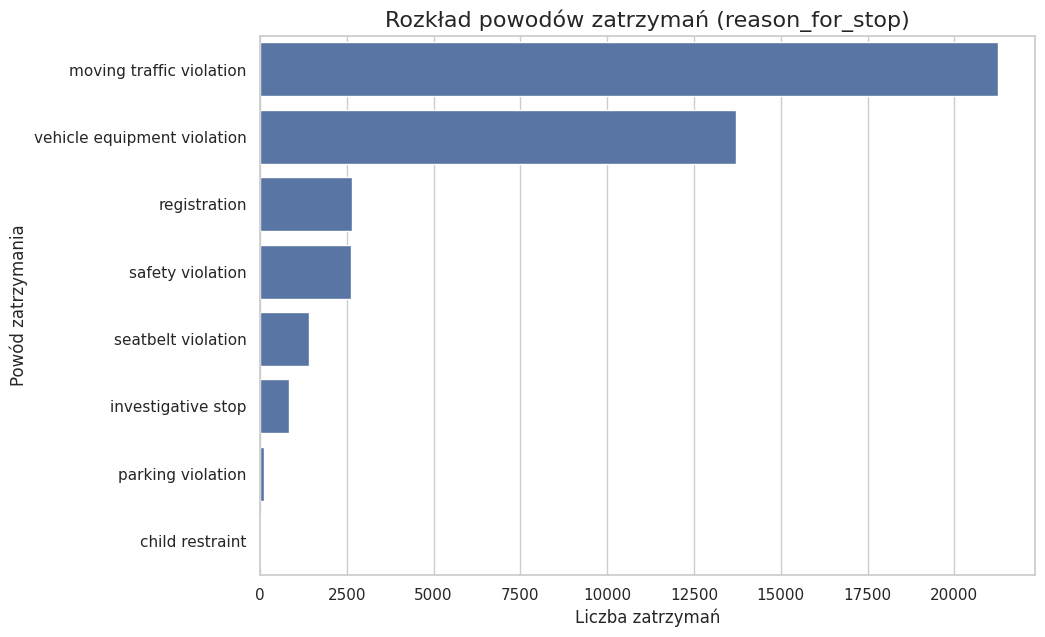

In [ ]:
# Rozkład dla powodu zatrzymania

column = "reason_for_stop"
counts = df[column].value_counts(dropna=True)

print(counts)

percent = ((df[column].value_counts(normalize=True) * 100).round(2)).astype(str) + '%'
print("\nUdział procentowy:")
print(percent)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.title(f'Rozkład powodów zatrzymań ({column})', fontsize=16)
plt.xlabel('Liczba zatrzymań')
plt.ylabel('Powód zatrzymania')
plt.show()

## Analiza relacji

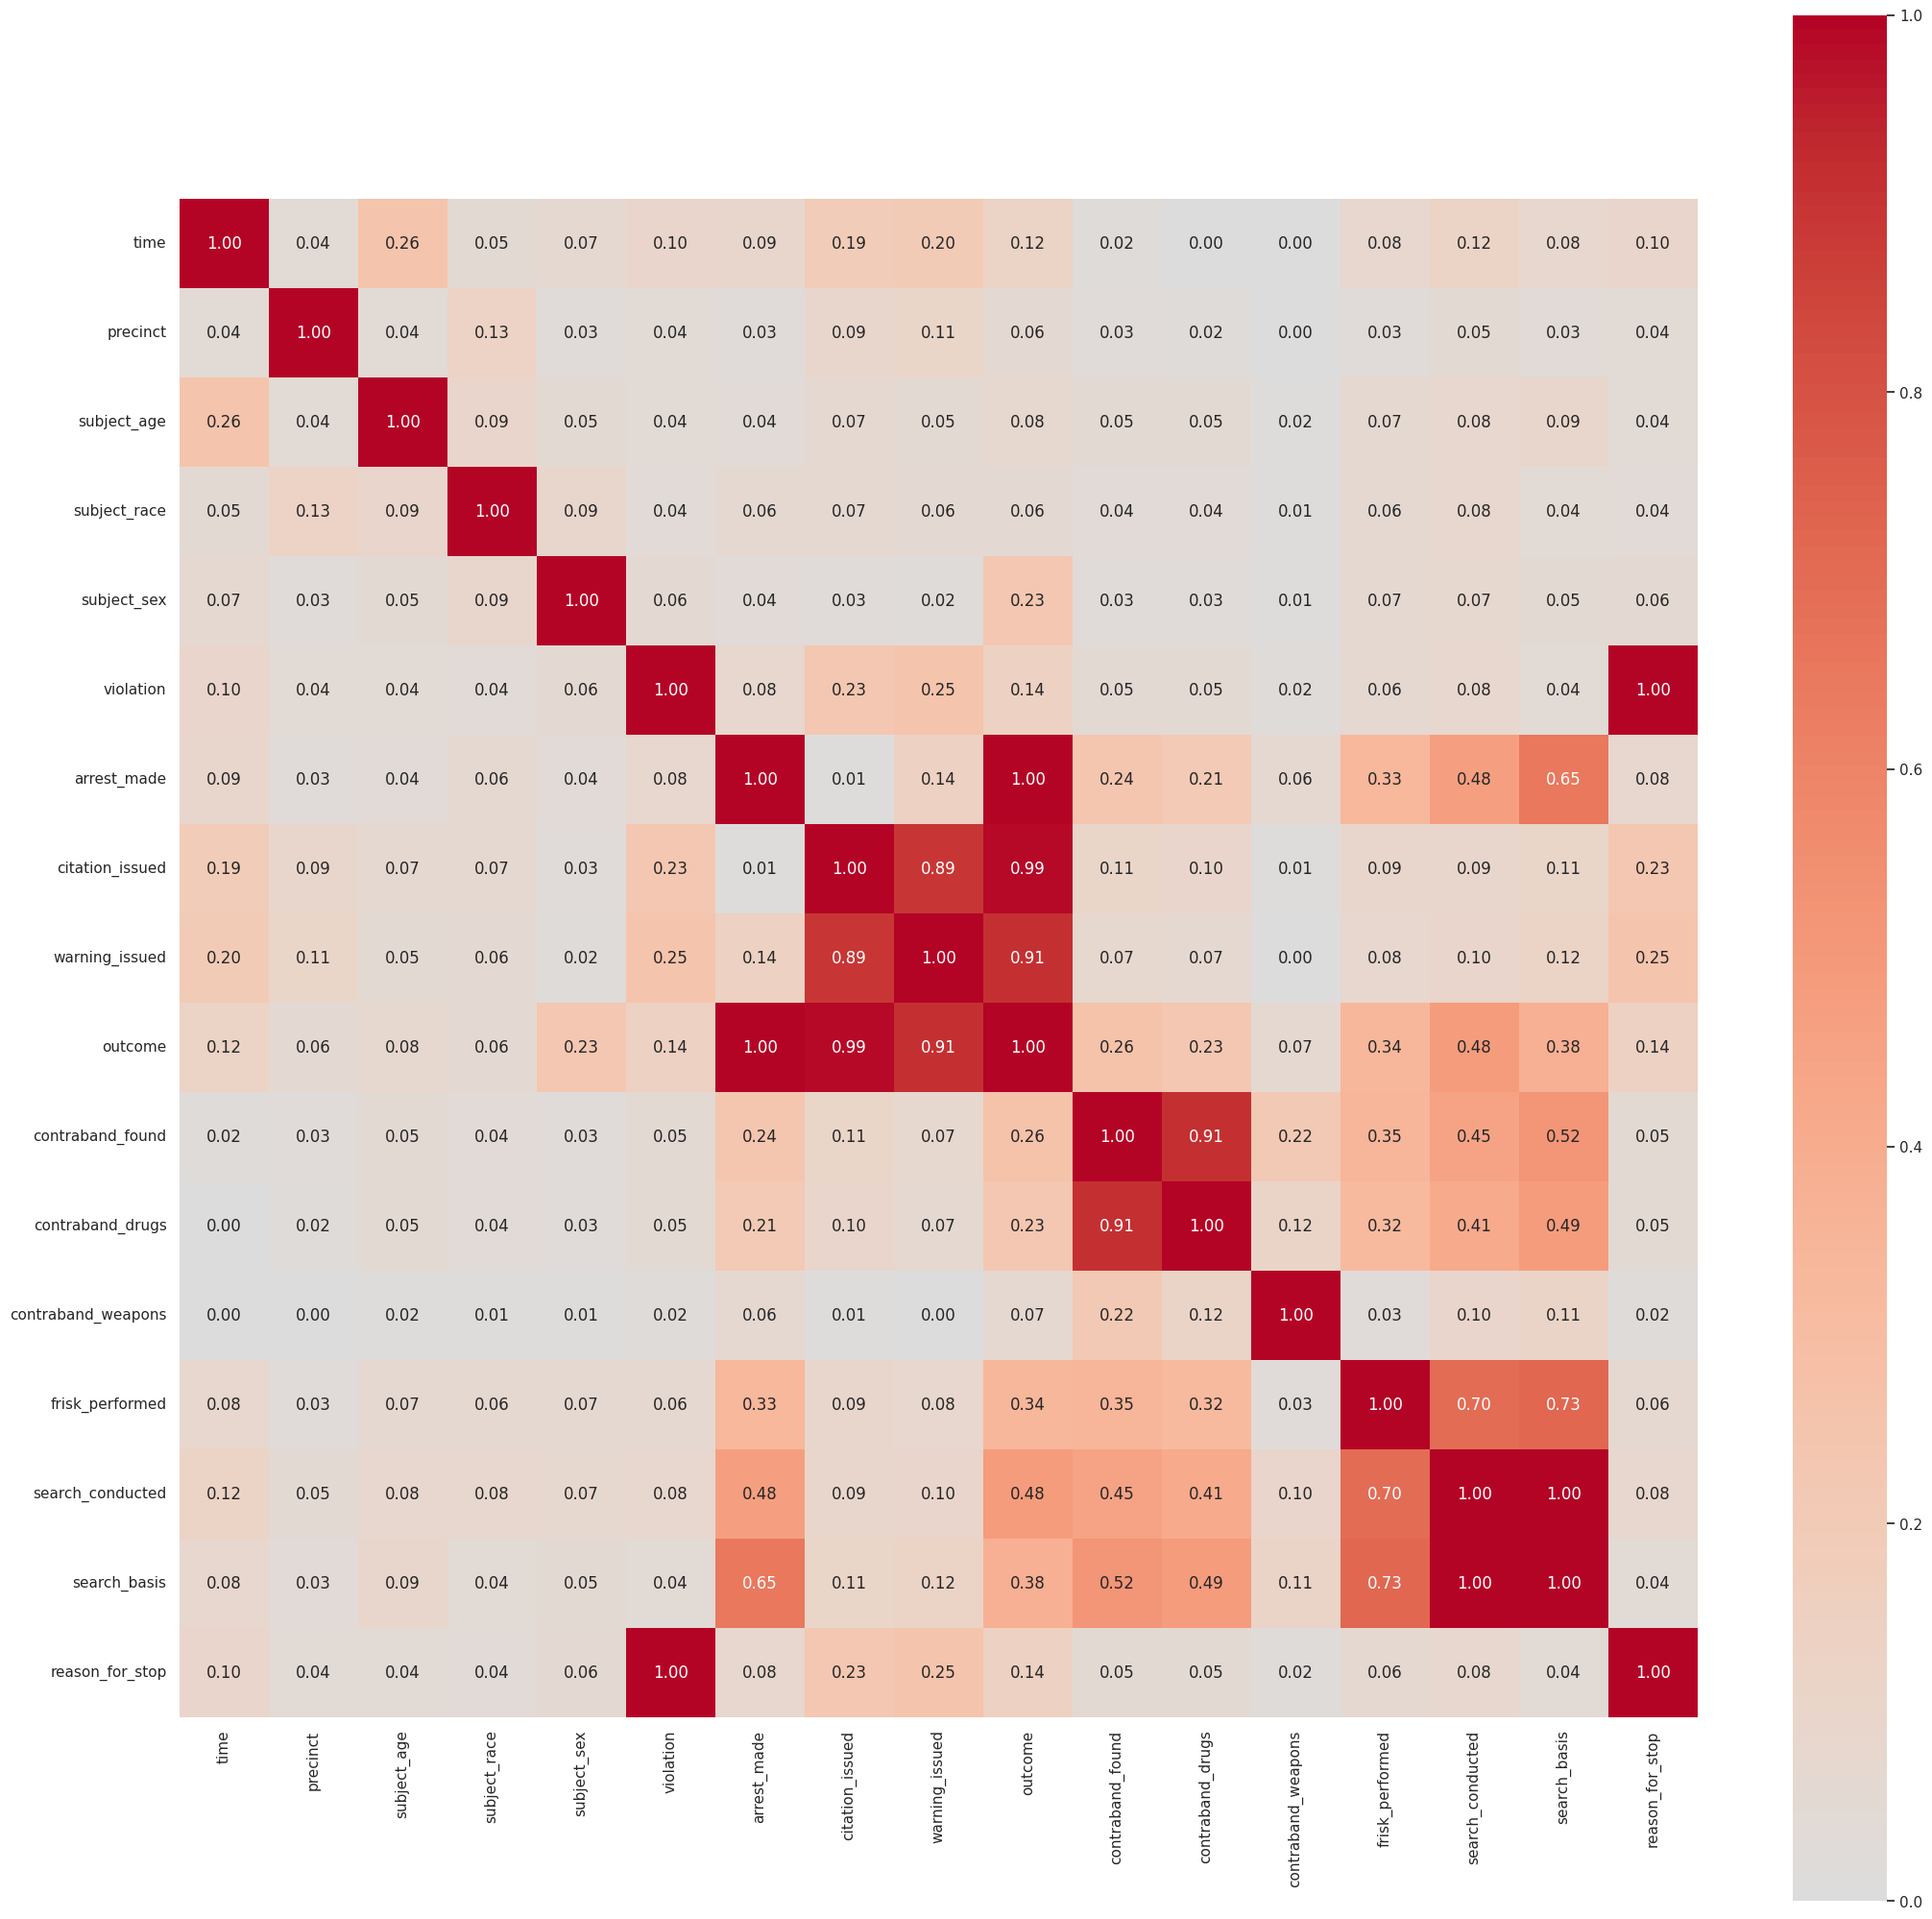

In [ ]:
assoc_results = associations(
    df,
    annot=True,
    fmt='.2f',
    cmap=colormaps["coolwarm"]
)

# Ekstrakcja wiedzy

## Klasyfikacja

## Random Forest

In [ ]:
df_prep = df.copy()
df_prep["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
df_prep["hour_of_day"] = df_prep["time_obj"].dt.hour
df_prep = df_prep.dropna(subset=["hour_of_day"])
df_prep["hour_of_day"] = df_prep["hour_of_day"].astype(int)

target_var = "arrest_made"

feature_list = [
    "subject_age", "subject_race", "subject_sex", "hour_of_day"
]
df_model = df_prep[feature_list + [target_var]].dropna(subset=[target_var])

# imputer = SimpleImputer(strategy='median')
# df_model["subject_age"] = imputer.fit_transform(df_model[["subject_age"]])

X = pd.get_dummies(df_model[feature_list], drop_first=True)
y = df_model[target_var].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
num_cols = ["subject_age", "hour_of_day"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=100
)

model.fit(X_train, y_train)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

              precision    recall  f1-score   support

           0       0.98      0.90      0.94      8386
           1       0.02      0.10      0.03       141

    accuracy                           0.88      8527
   macro avg       0.50      0.50      0.48      8527
weighted avg       0.97      0.88      0.92      8527



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

              precision    recall  f1-score   support

      arrest       0.03      0.07      0.04       212
    citation       0.33      0.40      0.36      2808
     warning       0.80      0.73      0.77      9763

    accuracy                           0.65     12783
   macro avg       0.39      0.40      0.39     12783
weighted avg       0.69      0.65      0.66     12783



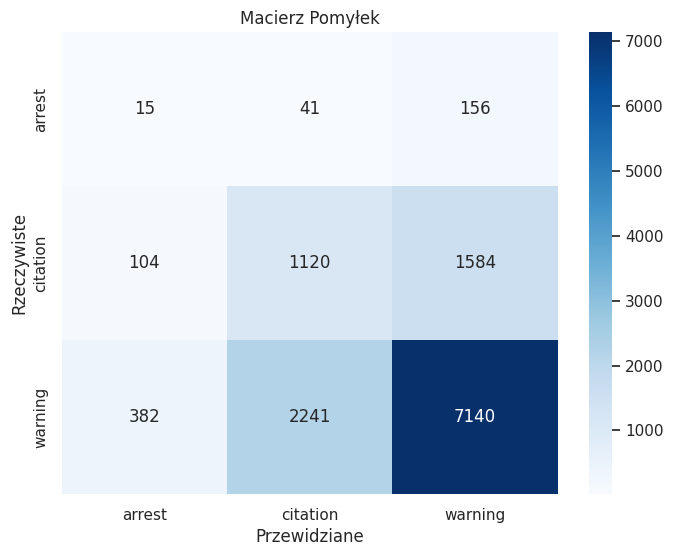

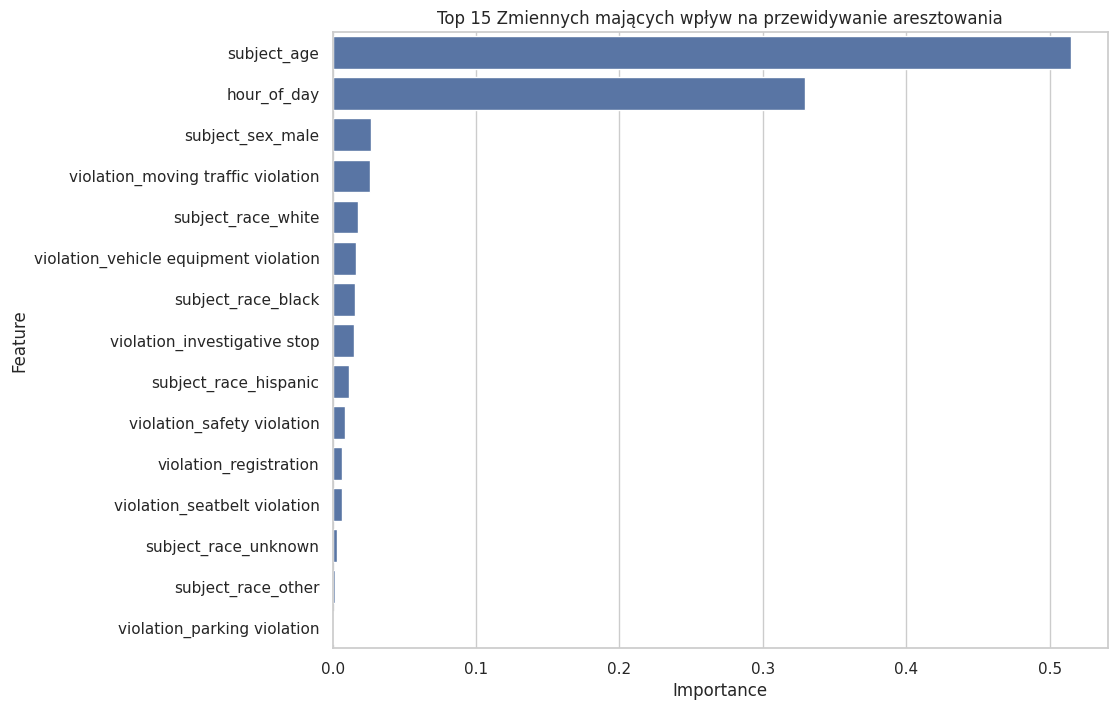

In [ ]:
# Old

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
class_labels = model.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Macierz Pomyłek')
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.show()

importances = model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Zmiennych mających wpływ na przewidywanie aresztowania')
plt.show()

## Regresja

In [ ]:
df_ra = df.copy()

df_ra["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
df_ra["hour_of_day"] = df_ra["time_obj"].dt.hour
df_ra = df_ra.dropna(subset=["hour_of_day", "subject_age"])
df_ra["hour_of_day"] = df_ra["hour_of_day"].astype(int)


feature_list = [
    "subject_race", "subject_sex", "violation", "hour_of_day", "precinct"
]

y = df_ra["subject_age"]
X = pd.get_dummies(df_ra[feature_list], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

num_cols = ["hour_of_day"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

model_reg = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10
)
model_reg.fit(X_train, y_train)

y_pred = model_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Wynik regresji:")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

if r2 < 0.1:
    print(f"Zmienne słabo opisują.")
else:
    print(f"Regresja myli się o: {mae:.2f} lat.")

Wynik regresji:
MAE: 11.37
R2: 0.045
Zmienne słabo opisują.


## Klasteryzacja

/tmp/ipython-input-140903633.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_kla_ano[contr_fill] = df_kla_ano[contr_fill].fillna(False)


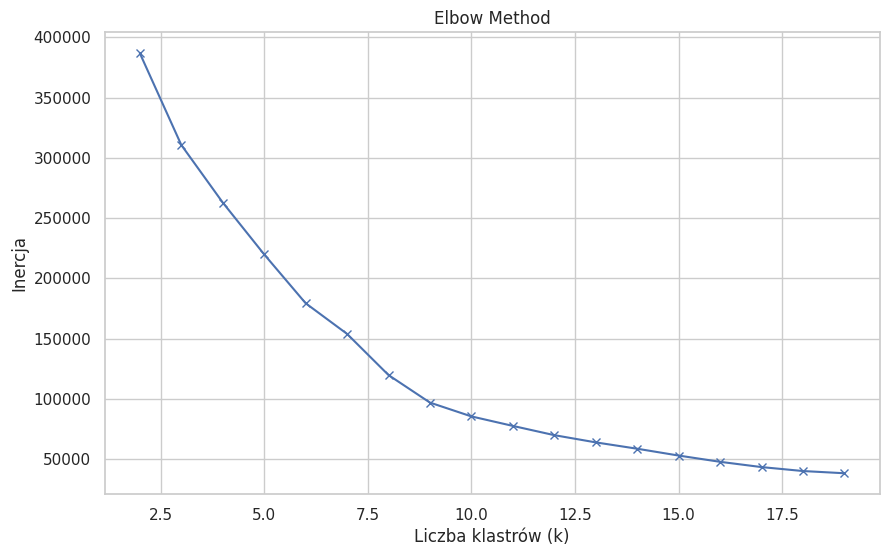

In [ ]:
df_kla_ano = df.copy()

df_kla_ano['time_obj'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce')
df_kla_ano['hour_of_day'] = df_kla_ano['time_obj'].dt.hour
df_kla_ano = df_kla_ano.dropna(subset=['hour_of_day', 'subject_age', 'subject_race', 'subject_sex'])

features_for_clustering = [
    'subject_age', 'subject_race', 'subject_sex', 'hour_of_day',
    "contraband_found", "contraband_drugs", "contraband_weapons"
]

contr_fill = ["contraband_found", "contraband_drugs", "contraband_weapons"]
df_kla_ano[contr_fill] = df_kla_ano[contr_fill].fillna(False)

df_features = df_kla_ano[features_for_clustering].copy()
df_processed = pd.get_dummies(df_features, drop_first=True)

imputer = SimpleImputer(strategy="median")
df_processed_imputed = imputer.fit_transform(df_processed)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_processed_imputed)

inertia_scores = {}
K_RANGE = range(2, 20)

for k in K_RANGE:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(df_scaled)
    inertia_scores[k] = kmeans_test.inertia_

plt.figure(figsize=(10, 6))
plt.plot(list(inertia_scores.keys()), list(inertia_scores.values()), 'bx-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inercja')
plt.title('Elbow Method')
plt.show()

In [ ]:
k = 10

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans.fit_predict(df_scaled)

df_kla_ano['cluster'] = cluster_labels

for i in range(k):
    print(f"\nKlaster {i}:")
    cluster_data = df_kla_ano[df_kla_ano['cluster'] == i]
    print(f"Średni wiek: {cluster_data['subject_age'].mean():.1f}")
    print(f"Najczęstsza rasa: {cluster_data['subject_race'].mode()[0]}")
    print(f"Najczęściej występujące płeć: {cluster_data['subject_sex'].mode()[0]}")
    print(f"Najczęstsza godzina: {cluster_data['hour_of_day'].median():.0f}")

    contr = cluster_data['contraband_found'].mean() * 100
    print(f"Procent z kontrabandą: {contr:.1f}%")

    if contr:
        contr_drugs = cluster_data['contraband_drugs'].mean() * 100
        contr_weapon = cluster_data['contraband_weapons'].mean() * 100

        print(f"Procent z narkotykami: {contr_drugs:.1f}%") if contr_drugs else None
        print(f"Procent z bronią: {contr_weapon:.1f}%") if contr_weapon else None


Klaster 0:
Średni wiek: 36.9
Najczęstsza rasa: black
Najczęściej występujące płeć: male
Najczęstsza godzina: 14
Procent z kontrabandą: 0.2%

Klaster 1:
Średni wiek: 35.3
Najczęstsza rasa: black
Najczęściej występujące płeć: female
Najczęstsza godzina: 15
Procent z kontrabandą: 0.0%

Klaster 2:
Średni wiek: 57.9
Najczęstsza rasa: white
Najczęściej występujące płeć: male
Najczęstsza godzina: 12
Procent z kontrabandą: 0.0%

Klaster 3:
Średni wiek: 33.5
Najczęstsza rasa: hispanic
Najczęściej występujące płeć: male
Najczęstsza godzina: 15
Procent z kontrabandą: 0.1%

Klaster 4:
Średni wiek: 28.6
Najczęstsza rasa: black
Najczęściej występujące płeć: male
Najczęstsza godzina: 15
Procent z kontrabandą: 100.0%
Procent z narkotykami: 100.0%

Klaster 5:
Średni wiek: 34.0
Najczęstsza rasa: white
Najczęściej występujące płeć: female
Najczęstsza godzina: 13
Procent z kontrabandą: 0.1%

Klaster 6:
Średni wiek: 35.6
Najczęstsza rasa: unknown
Najczęściej występujące płeć: male
Najczęstsza godzina: 13


## Anomalie

In [ ]:
iso_forest = IsolationForest(random_state=42)
anomaly_labels = iso_forest.fit_predict(df_scaled)

anomaly_scores = iso_forest.decision_function(df_scaled)
df_kla_ano['anomaly_score'] = anomaly_scores
df_kla_ano = df_kla_ano.sort_values(by='anomaly_score')

anomalies = df_kla_ano.head(20)
normal_data = df_kla_ano.tail(len(df_kla_ano) - 20)

# print(anomalies[features_for_clustering + ['anomaly_score']])

numeric_cols = [
    'subject_age', 'hour_of_day', 'contraband_found', 'contraband_drugs',
    'contraband_weapons', 'frisk_performed', 'search_conducted'
]

categorical_cols = ['subject_race', 'subject_sex', 'search_basis', 'precinct']

numeric_to_compare = [col for col in features_for_clustering if col in numeric_cols]
categorical_to_compare = [col for col in features_for_clustering if col in categorical_cols]

print("Porównanie Anomalia vs Norma")

print("Statystyki Anomalii:")
print(anomalies[numeric_to_compare].apply(pd.to_numeric, errors='coerce').describe().T)

print("Statystyki Normalnych Danych:")
print(normal_data[numeric_to_compare].apply(pd.to_numeric, errors='coerce').describe().T)

for col in categorical_to_compare:
    print(f"\n\nRozkład '{col}' w Anomaliach")
    print(anomalies[col].value_counts(normalize=True).head(3))
    print(f"\nRozkład '{col}' w Normalnych Danych")
    print(normal_data[col].value_counts(normalize=True).head(3))

Porównanie Anomalia vs Norma
Statystyki Anomalii:
             count   mean        std   min    25%   50%   75%   max
subject_age   20.0  38.35  13.708526  18.0  28.75  36.0  44.0  72.0
hour_of_day   20.0  13.35   6.466716   0.0   9.75  12.5  19.0  23.0
Statystyki Normalnych Danych:
               count       mean        std   min   25%   50%   75%   max
subject_age  42407.0  37.067064  14.037814  13.0  26.0  34.0  47.0  99.0
hour_of_day  42407.0  12.867946   6.704024   0.0   8.0  13.0  19.0  23.0


Rozkład 'subject_race' w Anomaliach
subject_race
white       0.65
black       0.25
hispanic    0.10
Name: proportion, dtype: float64

Rozkład 'subject_race' w Normalnych Danych
subject_race
white       0.542528
black       0.376259
hispanic    0.053152
Name: proportion, dtype: float64


Rozkład 'subject_sex' w Anomaliach
subject_sex
female    0.55
male      0.45
Name: proportion, dtype: float64

Rozkład 'subject_sex' w Normalnych Danych
subject_sex
male      0.594124
female    0.405876
Name

## Asocjacja i wzory

In [ ]:
df_aso = df.copy()

df_aso["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
df_aso["hour_of_day"] = df_aso["time_obj"].dt.hour
df_aso = df_aso.dropna(subset=["hour_of_day"])
df_aso["hour_of_day"] = df_aso["hour_of_day"].astype(int)

df_aso["age_bin"] = pd.cut(
    df_aso["subject_age"], bins=[0, 25, 40, 60, 100],
    labels=['Young', 'Adult', 'Old', 'Senior']
)

df_aso["hour_bin"] = pd.cut(
    df_aso["hour_of_day"], bins=[-1, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

df_aso['race'] = 'race' + df_aso['subject_race'].astype(str)
df_aso['sex'] = 'sex' + df_aso['subject_sex'].astype(str)
df_aso['arrest'] = 'arrest' + df_aso['arrest_made'].astype(str)
df_aso['search'] = 'search' + df_aso['search_conducted'].astype(str)

cols_for_rules = ["race", "sex", "arrest", "search", "age_bin", "hour_bin"]
df_rules = df_aso[cols_for_rules].dropna()

transactions = df_rules.values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_onehot, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules["pair_key"] = rules.apply(
    lambda row: row["antecedents"].union(row['consequents']),
    axis=1
)

rules = rules.sort_values(by=['lift', 'confidence'], ascending=False)
rules_nodup = rules.drop_duplicates(subset='pair_key', keep='first')
rules_final = rules_nodup.drop(columns=['pair_key'])

print("Największy wpłw na wzorzec:")
print("Jeśli A, to B występuje [lift] częściej\n")
print(rules_final[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

Największy wpłw na wzorzec:
Jeśli A, to B występuje [lift] częściej

                        antecedents             consequents   support  \
1656  (racewhite, Old, searchFalse)  (arrestFalse, Morning)  0.057672   
990   (racewhite, Old, searchFalse)               (Morning)  0.057766   
959          (arrestFalse, Morning)        (racewhite, Old)  0.058071   
272                (racewhite, Old)               (Morning)  0.058400   
887            (Young, searchFalse)  (Evening, arrestFalse)  0.070765   

      confidence      lift  
1656    0.358466  1.303123  
990     0.359049  1.292783  
959     0.211105  1.286249  
272     0.355826  1.281177  
887     0.306286  1.243112  
